<a href="https://colab.research.google.com/github/z-serra/PythonNotes4ML/blob/main/DecisionTreeAndRandomForestClassifiersNotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# decision tree / random forest

# nodes and edges
# root and leaves

# entropy and information gain for choosing the best split

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/refs/heads/master/csv/rpart/kyphosis.csv", index_col=0)

df.head()

,Kyphosis,Age,Number,Start
rownames,,,,
1,absent,71,3,5
2,absent,158,3,14
3,present,128,4,5
4,absent,2,5,1
5,absent,1,4,15


In [4]:
df.describe()

,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,83.654321,4.049383,11.493827
std,58.104251,1.619423,4.883962
min,1.000000,2.000000,1.000000
25%,26.000000,3.000000,9.000000
50%,87.000000,4.000000,13.000000
75%,130.000000,5.000000,16.000000
max,206.000000,10.000000,18.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81 entries, 1 to 81
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 3.2+ KB


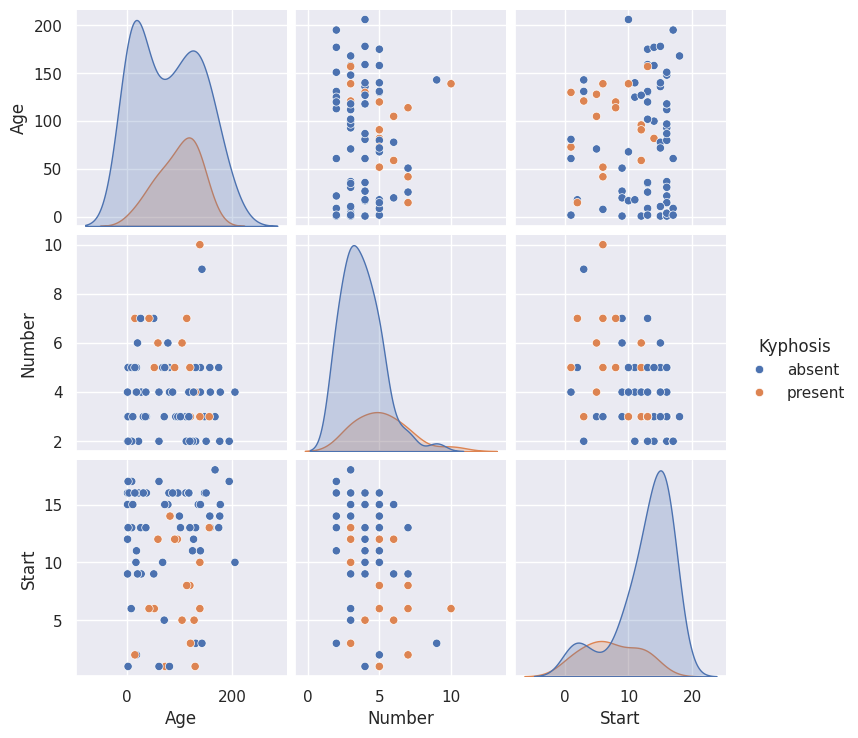

In [6]:
sns.pairplot(df, hue="Kyphosis")

In [7]:
X = df.drop('Kyphosis', axis=1)
y = df['Kyphosis']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()

dtree.fit(X_train, y_train)

predictions = dtree.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, predictions))

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

      absent       0.77      0.81      0.79        21
     present       0.20      0.17      0.18         6

    accuracy                           0.67        27
   macro avg       0.49      0.49      0.49        27
weighted avg       0.65      0.67      0.66        27



array([[17,  4],
       [ 5,  1]])

In [8]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=200)

rfc.fit(X_train, y_train)

predictions = rfc.predict(X_test)

print(classification_report(y_test, predictions))

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

      absent       0.80      0.95      0.87        21
     present       0.50      0.17      0.25         6

    accuracy                           0.78        27
   macro avg       0.65      0.56      0.56        27
weighted avg       0.73      0.78      0.73        27



array([[20,  1],
       [ 5,  1]])

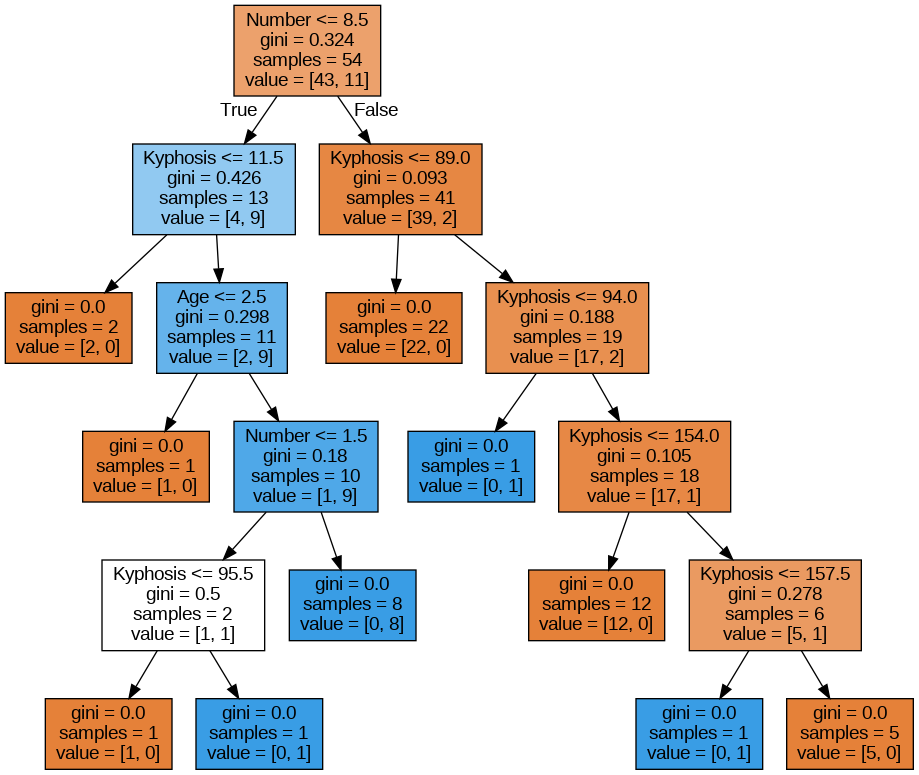

In [9]:
from IPython.display import Image
from io import StringIO
from sklearn.tree import export_graphviz
import pydot

features = list(df.columns[:-1])

dot_data = StringIO()

export_graphviz(dtree, out_file=dot_data, feature_names=features, filled=True)

graph = pydot.graph_from_dot_data(dot_data.getvalue())

Image(graph[0].create_png())

In [10]:
df = pd.read_csv("https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/refs/heads/master/Datasets/loan_data.csv")
df.head(1)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.1,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0


In [11]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


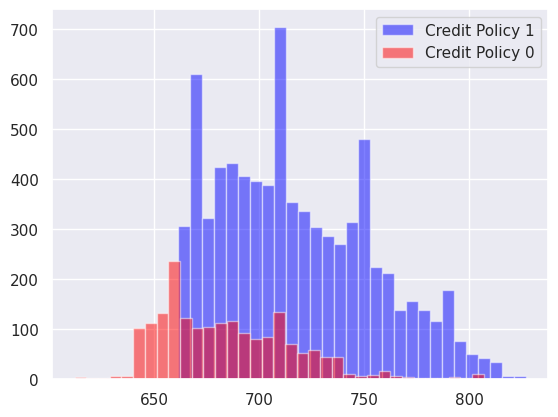

In [13]:
df[df['credit.policy'] == 1]["fico"].hist(bins=35, color="blue", label="Credit Policy 1", alpha=0.5)
df[df['credit.policy'] == 0]["fico"].hist(bins=35, color="red", label="Credit Policy 0", alpha=0.5)
plt.legend()

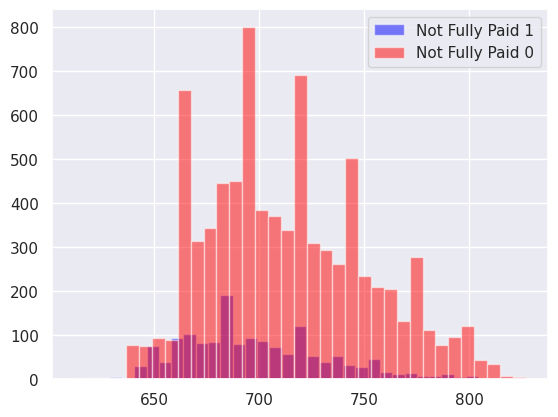

In [14]:
df[df['not.fully.paid'] == 1]["fico"].hist(bins=35, color="blue", label="Not Fully Paid 1", alpha=0.5)
df[df['not.fully.paid'] == 0]["fico"].hist(bins=35, color="red", label="Not Fully Paid 0", alpha=0.5)
plt.legend()

<Axes: xlabel='purpose', ylabel='count'>

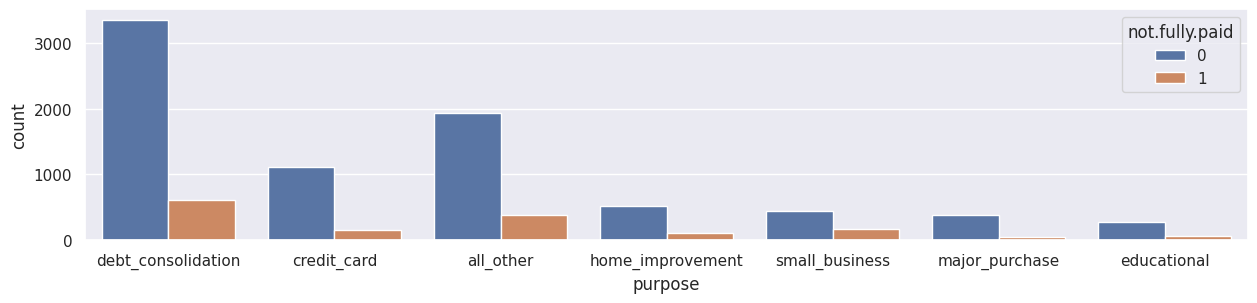

In [15]:
plt.figure(figsize=(15,3))
sns.countplot(data=df, x="purpose", hue="not.fully.paid")

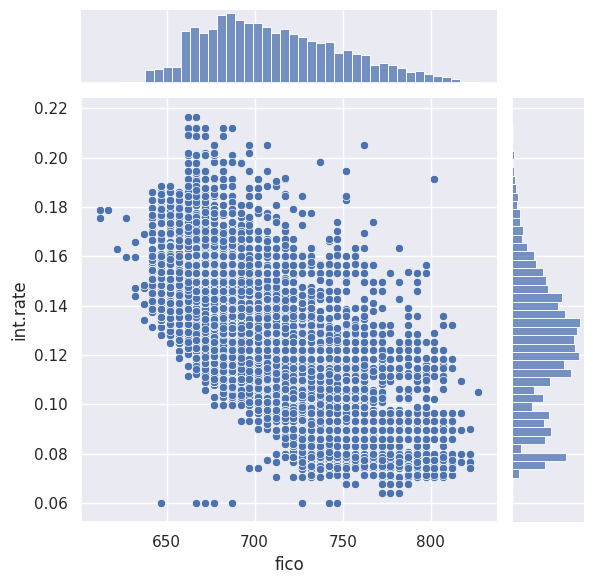

In [16]:
sns.jointplot(x=df['fico'], y=df['int.rate'])

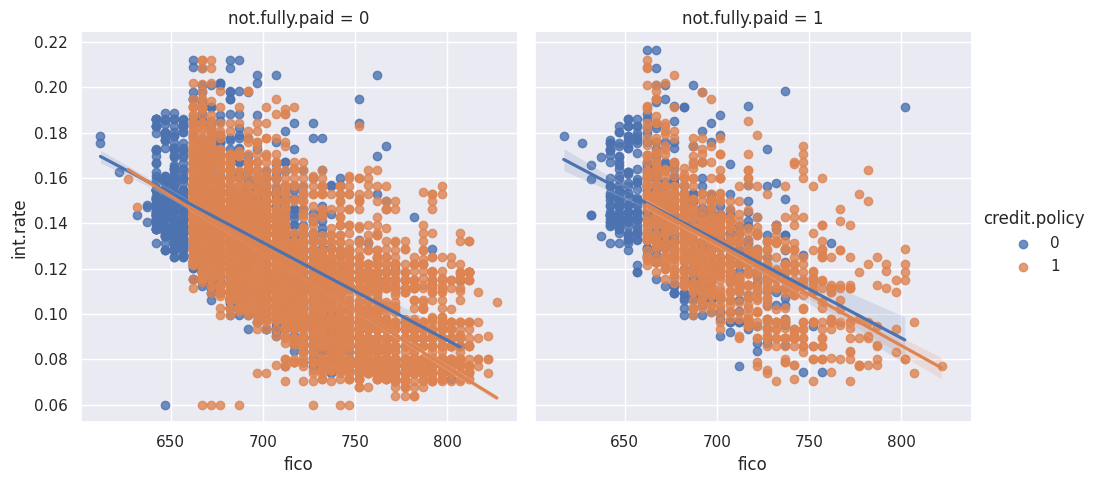

In [17]:
sns.lmplot(y='int.rate', x='fico', data=df, hue="credit.policy", col="not.fully.paid")

In [18]:
df = pd.get_dummies(df, columns=['purpose'], drop_first=True)

X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

dtree = DecisionTreeClassifier()

dtree.fit(X_train, y_train)

predictions = dtree.predict(X_test)

print(classification_report(y_test, predictions))

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      2650
           1       0.21      0.23      0.22       511

    accuracy                           0.74      3161
   macro avg       0.53      0.53      0.53      3161
weighted avg       0.75      0.74      0.74      3161



array([[2227,  423],
       [ 396,  115]])

In [19]:
rfc = RandomForestClassifier(n_estimators=200)

rfc.fit(X_train, y_train)

predictions = rfc.predict(X_test)

print(classification_report(y_test, predictions))

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      2650
           1       0.46      0.02      0.04       511

    accuracy                           0.84      3161
   macro avg       0.65      0.51      0.48      3161
weighted avg       0.78      0.84      0.77      3161



array([[2637,   13],
       [ 500,   11]])